## Preparamos las librerias que vamos a realizar

In [2]:

# importamos librerias que utilizaremos

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

# Crear lo Data Frame de los archivos para su uso
df_empresas = pd.read_csv('moved_project_sql_result_01.csv')
df_barrios = pd.read_csv('moved_project_sql_result_04.csv')
df_clima = pd.read_csv('moved_project_sql_result_07.csv')




In [ ]:
#Lexploracion de los datos contenidos
df_empresas.info()
df_empresas.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [ ]:
#Lexploracion de los datos contenidos
df_barrios.info()
df_barrios.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [ ]:
#Tomamos las 10 barrios mas concurridos
# Top de Viajes
top_10_barrios = df_barrios.sort_values(by='average_trips', ascending=False).head(10)
print(top_10_barrios)


  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


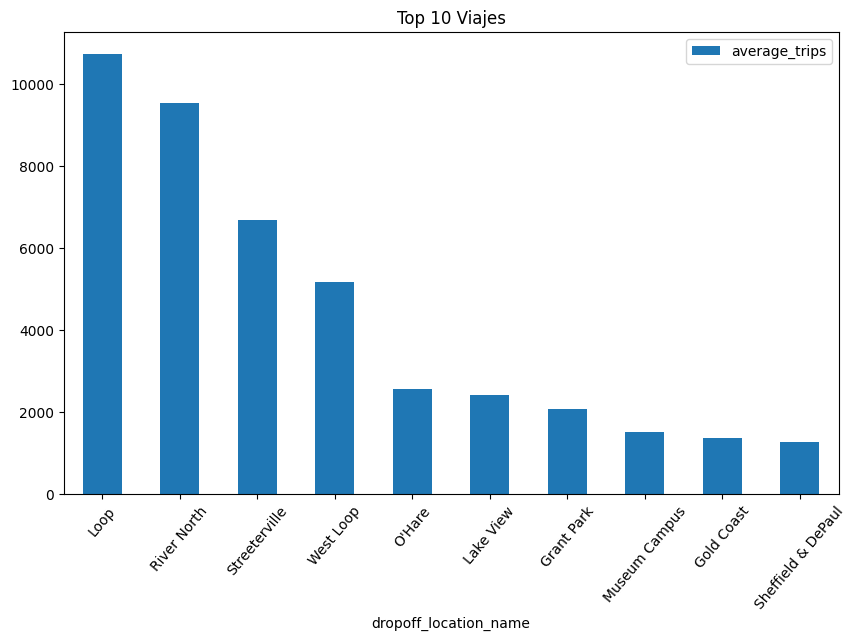

In [ ]:

# Creando el gráfico
top_10_barrios.plot(kind='bar', x='dropoff_location_name', y='average_trips', figsize=(10, 6), title='Top 10 Viajes', rot=50)

# Mostrando el gráfico en pantalla
plt.show()


In [ ]:
#Tomamos las empresa con mayor preferencia
# Top de Empresas
top_empresas = df_empresas.sort_values(by='trips_amount', ascending=False).head(15)
print(top_empresas)

                               company_name  trips_amount
0                                 Flash Cab         19558
1                 Taxi Affiliation Services         11422
2                         Medallion Leasing         10367
3                                Yellow Cab          9888
4           Taxi Affiliation Service Yellow          9299
5                 Chicago Carriage Cab Corp          9181
6                              City Service          8448
7                                  Sun Taxi          7701
8                 Star North Management LLC          7455
9         Blue Ribbon Taxi Association Inc.          5953
10                  Choice Taxi Association          5015
11                               Globe Taxi          4383
12                Dispatch Taxi Affiliation          3355
13                Nova Taxi Affiliation Llc          3175
14  Patriot Taxi Dba Peace Taxi Association          2235


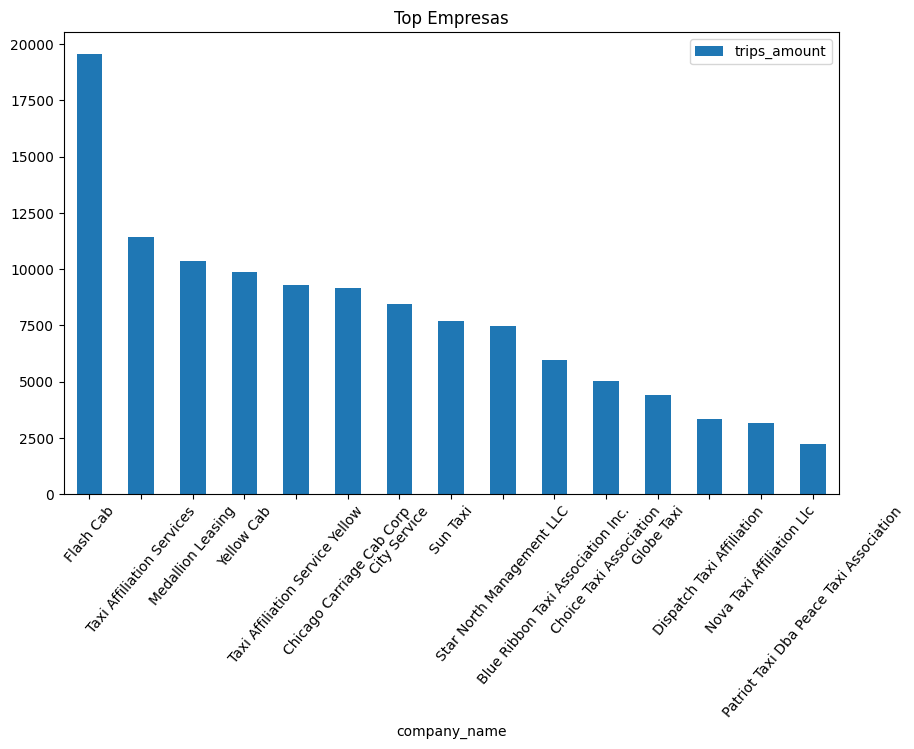

In [ ]:
# Creando el gráfico
top_empresas.plot(kind='bar', x='company_name', y='trips_amount', figsize=(10, 6), title='Top Empresas', rot=50)

# Mostrando el gráfico en pantalla
plt.show()

# Conclusiones

## El sitio más solicitado es loops seguido de cerca por River North y ya mas separado West Loop, en cuanto a la preferencia de la gente esta con Flash Cab por mucho!.

In [56]:
#Lexploracion de los datos contenidos
df_clima.info()
df_clima.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


## Plasmamos la hipotesis


### Hipótesis Nula (H0): La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es igual los sábados lluviosos y los sábados con buen clima.


### Hipótesis Alternativa (H1): La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia (es diferente) los sábados lluviosos en comparación con los sábados con buen clima.


### Nivel de significación ($\alpha$): 0.05

In [45]:
sunny_trips = df_clima[df_clima['weather_conditions'] == 'Good']['duration_seconds']
print(sunny_trips)

0       2410.0
1       1920.0
2       1543.0
3       2512.0
4       1440.0
         ...  
1062    1500.0
1063       0.0
1064    1318.0
1065    2100.0
1066    1380.0
Name: duration_seconds, Length: 888, dtype: float64


In [49]:
storm_trips = df_clima[df_clima['weather_conditions'] == 'Bad']['duration_seconds']
print(storm_trips)

6       2969.0
30      1980.0
34      2460.0
51      2760.0
52      2460.0
         ...  
1031    2560.0
1032    1908.0
1053    2400.0
1061    2186.0
1067    2834.0
Name: duration_seconds, Length: 180, dtype: float64


# Aqui vemos el resultado de la Hipotesis.

In [53]:
results = st.ttest_ind(sunny_trips, storm_trips, equal_var=False)
print(results)

Ttest_indResult(statistic=-7.186034288068629, pvalue=6.738994326108734e-12)


In [54]:
alpha = 0.05
p_value = results.pvalue

print(f'Valor p: {p_value}')

if p_value < alpha:
    print("Rechazamos la hipótesis nula.")
else:
    print("No podemos rechazar la hipótesis nula.")

Valor p: 6.738994326108734e-12
Rechazamos la hipótesis nula.


## Determinamos que el clima no influye en la duracion de los viajes que se realizan desde Loop hacia el Aeropuerto.

### He tenido que ir a las lecciones anteriores ya que son temas pasados como apoyo.